## NLP_text_mining 

Explainable AI Credit Risk Decision Platform Integrating Structured Borrower Data, NLP-Driven Text Intelligence, and Macroeconomic Indicators for Transparent Lending Decisions.

#### Reason:
The objective is to evaluate the quantity and characteristics of the text before feature engineering using TF-IDF.

In [91]:
# Standard Library
# ________________________________________________

import os
import re
import string
import warnings
import logging
from pathlib import Path
from collections import Counter


# Data Manipulation

import numpy as np
import pandas as pd
import seaborn as sns

# Visualisation

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# NLP

import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.util import ngrams
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud

# Notebook Display

from IPython.display import display

# Ignore unnecessary warnings

warnings.filterwarnings("ignore")

In [56]:
# Logging Congiguration
# ________________________________________________

logging.basicConfig(level=logging.INFO,

    format="%(asctime)s | %(levelname)s | %(message)s")

logger = logging.getLogger(__name__)

logger.info("NLP Text Mining Notebook Started")

2026-07-03 00:58:59,367 | INFO | NLP Text Mining Notebook Started


In [57]:
# Define paths
# ________________________________________________
 
REPORT_DIR = Path("reports")

ROOT = Path("..")

DATA_DIR = ROOT / "data"

logger.info("Project folders verified.")

FIGURE_DIR = REPORT_DIR / "figures"

# Create directories

REPORT_DIR.mkdir(parents=True, exist_ok=True)

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

REPORT_DIR = Path("reports/eda/unstructured")

REPORT_DIR.mkdir(parents=True, exist_ok=True)

2026-07-03 00:59:01,218 | INFO | Project folders verified.


In [99]:
# Project configuration
# ________________________________________________

TEXT_COLUMN = "title"

TARGET_COLUMN = "target"

MAX_TFIDF_FEATURES = 1000

MIN_DOCUMENT_FREQUENCY = 5

RANDOM_STATE = 42

TOP_N_WORDS = 20

TOP_N_BIGRAMS = 20

TOP_N_TRIGRAMS = 20

logger.info("Configuration loaded.")

2026-07-03 10:59:00,099 | INFO | Configuration loaded.


In [100]:
# Data Overview
# ________________________________________________

# creating EDA dataset from training data

X_train_nlp = X_train.copy()

# target EDA dataset from trainning data

X_train_nlp["target"] = y_train.values

print(X_train_eda.shape)

X_train_nlp.head()

(400000, 95)


,mths_since_recent_inq,emp_title,emp_length,num_tl_120dpd_2m,mo_sin_old_il_acct,bc_util,percent_bc_gt_75,bc_open_to_buy,mths_since_recent_bc,last_pymnt_d,...,url,grade,pymnt_plan,issue_d,verification_status,annual_inc,home_ownership,disbursement_method,id,target
409428,19.0,LAB TECHNICIAN,10+ years,0.0,162.0,95.9,100.0,575.0,57.0,Mar-2019,...,https://lendingclub.com/browse/loanDetail.acti...,B,n,Jan-2015,Source Verified,44096.3,RENT,Cash,38547678,0
6851,8.0,Registered Nurse,1 year,0.0,107.0,70.2,66.7,7986.0,8.0,Jan-2017,...,https://lendingclub.com/browse/loanDetail.acti...,A,n,Dec-2015,Not Verified,90000.0,MORTGAGE,Cash,68142357,0
278277,1.0,Meteorologist,< 1 year,0.0,93.0,71.2,25.0,3482.0,43.0,Oct-2015,...,https://lendingclub.com/browse/loanDetail.acti...,B,n,May-2015,Source Verified,52200.0,RENT,Cash,49773455,0
427606,8.0,Feeder Driver,10+ years,0.0,31.0,79.8,66.7,2622.0,17.0,Mar-2019,...,https://lendingclub.com/browse/loanDetail.acti...,E,n,Mar-2018,Source Verified,80000.0,MORTGAGE,Cash,130751884,0
149465,19.0,Education Coordinator,10+ years,0.0,90.0,52.1,16.7,5749.0,22.0,Jun-2016,...,https://lendingclub.com/browse/loanDetail.acti...,C,n,Sep-2015,Source Verified,36000.0,MORTGAGE,Cash,59301224,0


In [49]:
# Data Validation
# ________________________________________________

required_columns = [TEXT_COLUMN,TARGET_COLUMN]

missing_columns = [

    column

    for column in required_columns

    if column not in X_train_nlp.columns]

if missing_columns:

    raise ValueError(f"Missing required columns: {missing_columns}")

logger.info("Dataset validation completed successfully.")

2026-07-03 00:01:36,518 | INFO | Dataset validation completed successfully.


#### Text Cleaning & Preprocessing 

In [101]:
# TEXT CLEANING FUNCTION
# ________________________________________________

def clean_text(text):

# Handle missing values
    if pd.isna(text):
        return ""

# Convert to string
    text = str(text)

# Lowercase
    text = text.lower()

# Remove punctuation
    text = text.translate(
        str.maketrans(
            "",
            "",
            string.punctuation))

# Remove numbers
    text = re.sub(
        r"\d+",
        "",
        text)

# Remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

# Remove stop words
    words = [

        word

        for word in text.split()

        if word not in STOP_WORDS]

    return " ".join(words)

In [102]:
# APPLY TEXT CLEANING
# ________________________________________________

STOP_WORDS = ENGLISH_STOP_WORDS

logger.info("Cleaning title text...")

X_train_nlp["clean_title"] = (X_train_nlp[TEXT_COLUMN]

    .apply(clean_text))

logger.info("Text cleaning completed.")

2026-07-03 11:00:04,980 | INFO | Cleaning title text...
2026-07-03 11:00:06,958 | INFO | Text cleaning completed.


In [108]:
# Compare original vs clean words
# ________________________________________________

comparison = pd.DataFrame({

    "Original":

        X_train_nlp[TEXT_COLUMN].head(10),

    "Cleaned":

        X_train_nlp["clean_title"].head(10)})

display(comparison)

,Original,Cleaned
409428,Credit card refinancing,credit card refinancing
6851,Debt consolidation,debt consolidation
278277,Debt consolidation,debt consolidation
427606,Home improvement,home improvement
149465,Home improvement,home improvement
363478,Debt consolidation,debt consolidation
494216,Debt consolidation,debt consolidation
129594,Debt consolidation,debt consolidation
440797,Car financing,car financing
203761,Debt consolidation,debt consolidation


In [109]:
# Text Preprocessing Report
# ________________________________________________

original_text = (

    X_train_nlp[TEXT_COLUMN]

    .fillna(""))

clean_text_data = (

    X_train_nlp["clean_title"])

preprocessing_report = {

    "Metric":["Total Documents",
              
              "Missing Original",
              
              "Empty After Cleaning",
              
              "Average Original Length",
              
              "Average Clean Length",
              
              "Maximum Length",
              
              "Minimum Length"],

    "Value":[len(X_train_nlp),
             
             original_text.isna().sum(),
             
             (clean_text_data=="").sum(),
             
             round(original_text.astype(str)

            .str.len()

            .mean(),2),

        round(clean_text_data

            .str.len()

            .mean(),2),

        clean_text_data

        .str.len()

        .max(),

        clean_text_data

        .str.len()

        .min()]}

preprocessing_report = pd.DataFrame(preprocessing_report)

display(preprocessing_report)

,Metric,Value
0,Total Documents,400000.00
1,Missing Original,0.00
2,Empty After Cleaning,21190.00
3,Average Original Length,18.07
4,Average Clean Length,17.79
5,Maximum Length,30.00
6,Minimum Length,0.00


In [110]:
# Save Report
# ________________________________________________

preprocessing_report.to_csv(REPORT_DIR/"text_preprocessing_report.csv",index=False)

logger.info("Text preprocessing report exported.")

2026-07-03 11:06:32,221 | INFO | Text preprocessing report exported.


In [111]:
# VOCABULARY REDUCTION
# ________________________________________________

original_vocab = set(" ".join(original_text
    
    .astype(str)).split())

clean_vocab = set(" ".join(

        clean_text_data).split())

vocabulary_report = pd.DataFrame({"Metric":["Original Vocabulary",
                                            
                                            "Clean Vocabulary",
                                            
                                            "Words Removed"],
                                  
                                  "Value":[len(original_vocab),
                                           
                                           len(clean_vocab),
                                           
                                           len(original_vocab)-len(clean_vocab)]})

display(vocabulary_report)

vocabulary_report.to_csv(REPORT_DIR/"vocabulary_statistics.csv",index=False)

,Metric,Value
0,Original Vocabulary,56
1,Clean Vocabulary,44
2,Words Removed,12


In [113]:
# Cleaning Validation 
# ________________________________________________

logger.info("Running preprocessing validation...")

assert "clean_title" in X_train_nlp.columns

assert X_train_nlp["clean_title"].isnull().sum()==0

logger.info("Validation passed.")

2026-07-03 11:07:04,088 | INFO | Running preprocessing validation...
2026-07-03 11:07:04,132 | INFO | Validation passed.


#### Text Quality Assessment

##### Purpose: Assess the quality of the loan purpose
##### text after preprocessing

In [115]:
# Create Text Statistics
# ________________________________________________

logger.info("Generating text quality statistics...")

# Character length

X_train_nlp["character_length"] = (X_train_nlp["clean_title"].str.len())

# Word count

X_train_nlp["word_count"] = (X_train_nlp["clean_title"]
    
    .fillna("").str.split().str.len())

display(X_train_nlp[["clean_title",
                     
                     "character_length","word_count"]].head())

2026-07-03 11:07:39,284 | INFO | Generating text quality statistics...


,clean_title,character_length,word_count
409428,credit card refinancing,23,3
6851,debt consolidation,18,2
278277,debt consolidation,18,2
427606,home improvement,16,2
149465,home improvement,16,2


In [128]:
# Produce Summary Statistics
# ________________________________________________

quality_report = pd.DataFrame({

    "Metric":["Total Records",
              
              "Missing Original Purpose",
              
              "Empty Clean title",
              
              "Average Characters",
              
              "Median Characters",
              
              "Maximum Characters",
              
              "Minimum Characters",
              
              "Average Words",
              
              "Median Words",
              
              "Maximum Words",
              
              "Minimum Words"],

    "Value":[len(X_train_nlp),
             
             X_train_nlp["title"].isna().sum(),
             
             (X_train_nlp["clean_title"]=="").sum(),
             
             round(X_train_nlp["character_length"].mean(),2),
             
             X_train_nlp["character_length"].median(),
             
             X_train_nlp["character_length"].max(),
             
             X_train_nlp["character_length"].min(),
             
             round(X_train_nlp["word_count"].mean(),2),
             
             X_train_nlp["word_count"].median(),
             
             X_train_nlp["word_count"].max(),
             
             X_train_nlp["word_count"].min()]})

display(quality_report)

,Metric,Value
0,Total Records,400000.00
1,Missing Original Purpose,111.00
2,Empty Clean title,21190.00
3,Average Characters,17.79
4,Median Characters,18.00
5,Maximum Characters,30.00
6,Minimum Characters,0.00
7,Average Words,2.12
8,Median Words,2.00
9,Maximum Words,4.00


In [222]:
# Save Report
# ________________________________________________

quality_report.to_csv(REPORT_DIR /"title_text_quality_report.csv",index=False)

logger.info("Title text quality report exported.")

2026-07-04 00:44:16,471 | INFO | Title text quality report exported.


In [223]:
# Vocabulary Size
# ________________________________________________

logger.info("Calculating vocabulary statistics...")

all_words = " ".join(X_train_nlp["clean_title"]).split()

unique_words = set(all_words)

vocabulary_statistics = pd.DataFrame({"Metric":["Total Tokens",
                                                
                                                "Unique Words",
                                                
                                                "Vocabulary Richness"],
                                      
                                      "Value":[len(all_words)
                                               
                                               ,len(unique_words)
                                               
                                               ,round(len(unique_words)/len(all_words),4)]})

display(vocabulary_statistics)

vocabulary_statistics.to_csv(REPORT_DIR /"vocabulary_statistics.csv",index=False)

2026-07-04 00:44:22,106 | INFO | Calculating vocabulary statistics...


,Metric,Value
0,Total Tokens,847786.0000
1,Unique Words,44.0000
2,Vocabulary Richness,0.0001


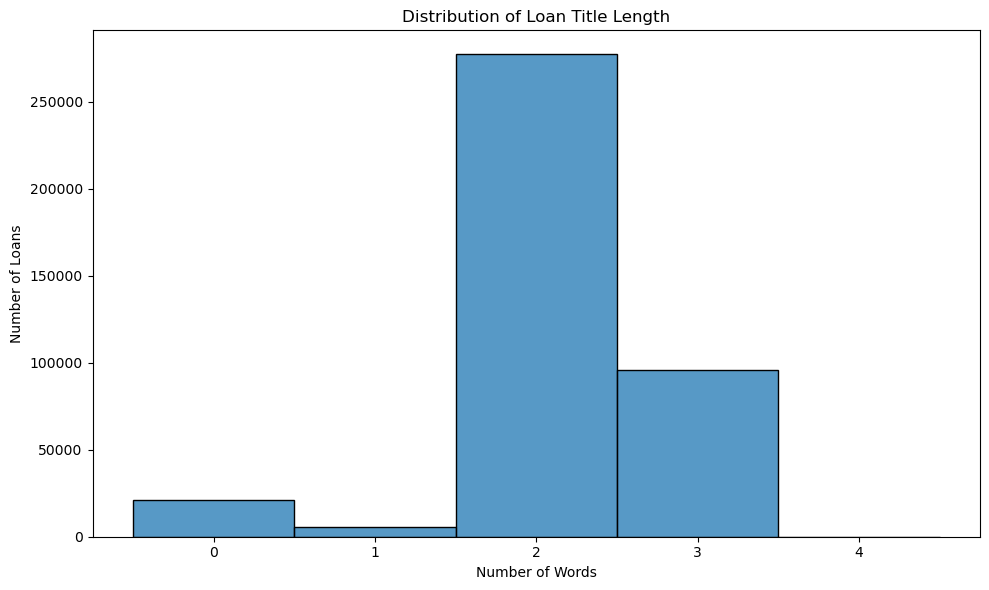

In [126]:
# Text Length Distribution
# ________________________________________________

plt.figure(figsize=(10,6))

sns.histplot(X_train_nlp["word_count"],
             
             bins=30,

             discrete=True,
             
             edgecolor="black")

plt.title("Distribution of Loan Title Length")

plt.xlabel("Number of Words")

plt.ylabel("Number of Loans")

plt.tight_layout()

plt.savefig(FIGURE_DIR /"title_length_distribution.png",dpi=300)

plt.show()

In [224]:
# Text Quality Executive Summary
# ________________________________________________

summary = f"""

TEXT QUALITY EXECUTIVE SUMMARY

Training Records

{len(X_train_nlp):,}

Average Purpose Length

{X_train_nlp['word_count'].mean():.2f} words

Median title Length

{X_train_nlp['word_count'].median():.0f} words

Longest title

{X_train_nlp['word_count'].max()} words

Vocabulary Size

{len(unique_words):,}

Missing Title

{X_train_nlp['title'].isna().sum():,}

Empty Clean Title

{(X_train_nlp['clean_title']=="").sum():,}

"""

print(summary)

with open(REPORT_DIR /"executive_summary.txt","w",encoding="utf-8"
         
         ) as f:f.write(summary)



TEXT QUALITY EXECUTIVE SUMMARY

Training Records

400,000

Average Purpose Length

2.18 words

Median title Length

2 words

Longest title

7 words

Vocabulary Size

44

Missing Title

111

Empty Clean Title

21,190




In [137]:
# Most Frequent Words
# ________________________________________________

logger.info("Calculating word frequencies...")

all_words = []

for text in X_train_nlp["clean_title"]:

    all_words.extend(text.split())

word_counts = Counter(all_words)

top_words = (pd.DataFrame(word_counts.items(),
                          
                          columns=["Word","Frequency"])
    
    .sort_values(by="Frequency",
                 
                 ascending=False)

    .reset_index(drop=True))

top_words = top_words.head(20)

display(top_words)

# Save Report

top_words.to_csv(REPORT_DIR /"top20_words.csv",index=False)

2026-07-03 12:25:01,422 | INFO | Calculating word frequencies...


,Word,Frequency
0,debt,232284
1,consolidation,232284
2,credit,95833
3,card,95833
4,refinancing,95832
5,home,26874
6,improvement,24773
7,purchase,7852
8,major,7852
9,expenses,4176


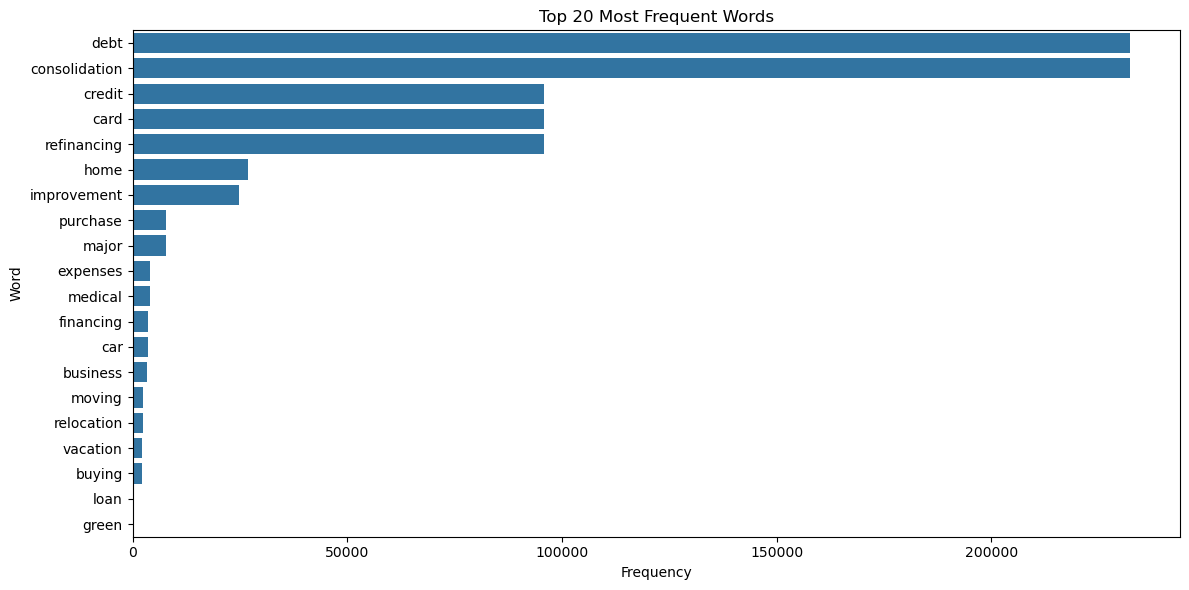

In [139]:
# Plot most frequent words
# ________________________________________________

plt.figure(figsize=(12,6))

sns.barplot(data=top_words,
            
            x="Frequency",
            
            y="Word")

plt.title("Top 20 Most Frequent Words")

plt.tight_layout()

plt.savefig(FIGURE_DIR/"top20_words.png",dpi=300)

plt.show()

In [225]:
# Business Interpretation
# ________________________________________________

business_text = f"""

TOP WORD ANALYSIS

The most frequently occurring loan title words are

{', '.join(top_words.Word.head(10))}.

This indicates that borrowers primarily request loans for
consumer finance purposes including debt refinancing,
credit card repayment and home improvement.

These words will later be converted into TF-IDF features
to investigate whether textual information improves
credit risk prediction.

"""

with open(REPORT_DIR/

    "word_frequency_summary.txt",

    "w",

    encoding="utf-8") as f:

    f.write(business_text)

### Bigram Analysis

In [147]:
# Top 20 Bigram Analysis
# ________________________________________________

logger.info("Generating bigrams...")

bigram_vectorizer = CountVectorizer(

    ngram_range=(2,2),

    stop_words="english",

    min_df=5)

X_bigram = bigram_vectorizer.fit_transform(X_train_nlp["clean_title"])

bigram_counts = (np.asarray(X_bigram.sum(axis=0)).flatten())

bigrams = pd.DataFrame({"Bigram":bigram_vectorizer.get_feature_names_out()
                        
                        ,"Frequency":bigram_counts})

bigrams = (bigrams.sort_values(by="Frequency",ascending=False).head(20))

display(bigrams)

2026-07-03 13:03:03,169 | INFO | Generating bigrams...


,Bigram,Frequency
3,debt consolidation,232284
1,card refinancing,95832
2,credit card,95832
6,home improvement,24773
7,major purchase,7852
8,medical expenses,4176
0,car financing,3570
9,moving relocation,2335
5,home buying,2101
4,green loan,204


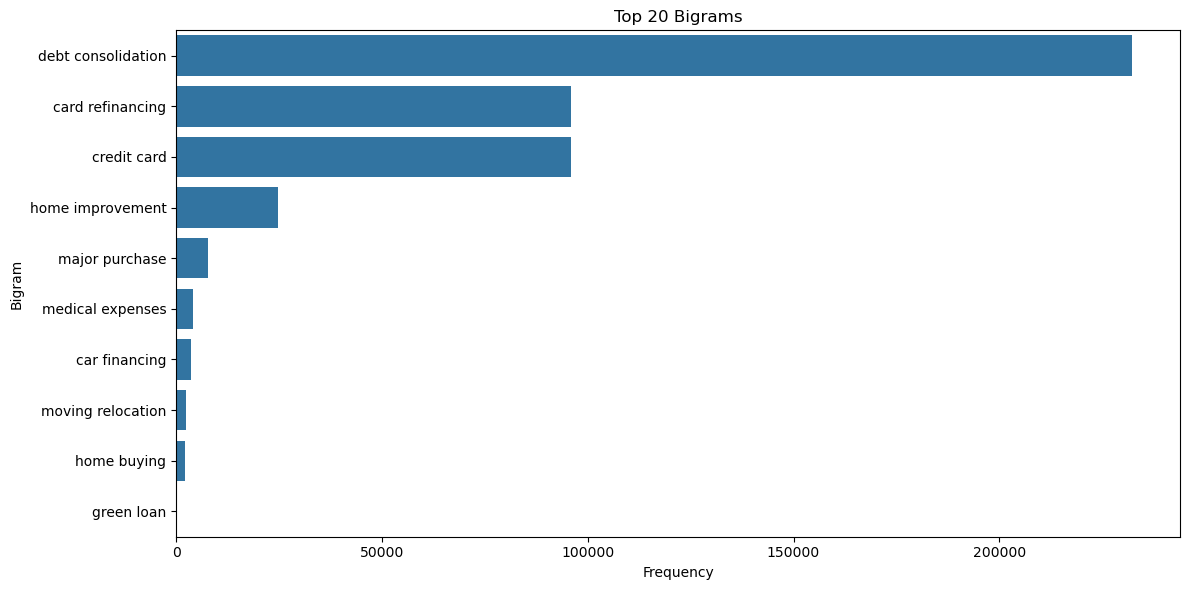

In [149]:
# Plot Top 20 bigram
# ________________________________________________

plt.figure(figsize=(12,6))

sns.barplot(data=bigrams,
            
            x="Frequency",
            
            y="Bigram")

plt.title("Top 20 Bigrams")

plt.tight_layout()

plt.savefig(FIGURE_DIR/"top20_bigrams.png",dpi=300)

plt.show()

#### Trigram Analysis

In [151]:
# Trigram Analysis 
# ________________________________________________

logger.info("Generating trigram frequencies...")

from sklearn.feature_extraction.text import CountVectorizer

trigram_vectorizer = CountVectorizer(ngram_range=(3,3),
                                     
                                     stop_words="english",min_df=5)

X_trigram = trigram_vectorizer.fit_transform(

    X_train_nlp["clean_title"])

trigram_counts = np.asarray(

    X_trigram.sum(axis=0)).flatten()

trigrams = pd.DataFrame({"Trigram": trigram_vectorizer.get_feature_names_out(),
                         
                         "Frequency": trigram_counts})

trigrams = (trigrams.sort_values(by="Frequency",
                                 
                                 ascending=False).head(20))

display(trigrams)

# Save Trigram Report

trigrams.to_csv(NLP_REPORT_DIR /"top20_trigrams.csv",index=False)

2026-07-03 13:24:01,989 | INFO | Generating trigram frequencies...


,Trigram,Frequency
0,credit card refinancing,95832


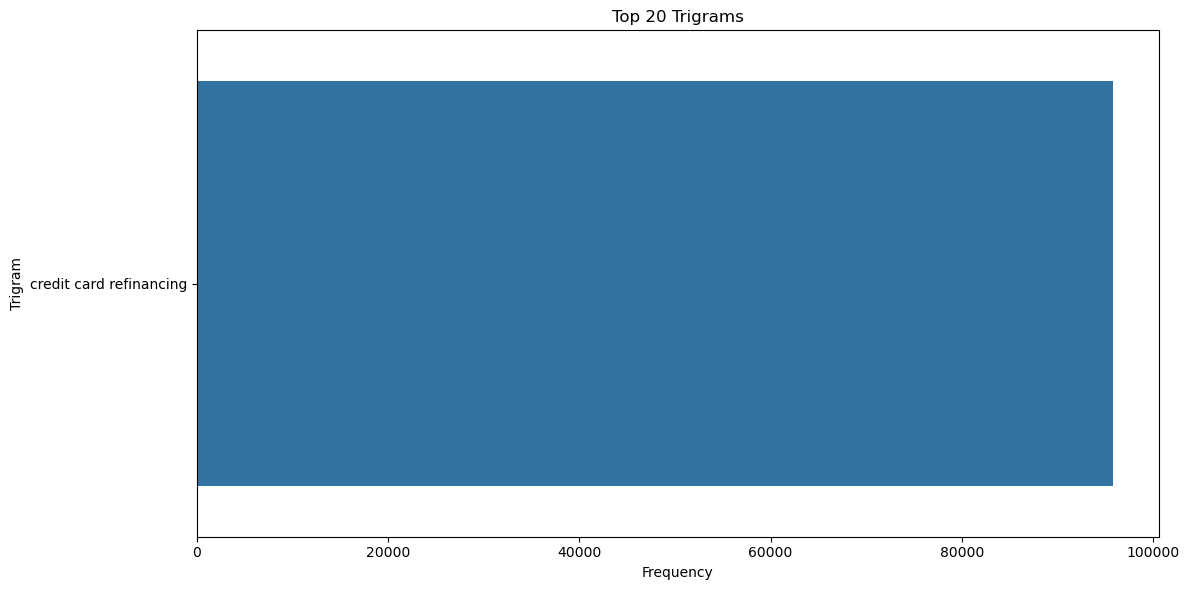

In [152]:
# Plot Top 20 Trigrams
# ________________________________________________

plt.figure(figsize=(12,6))

sns.barplot(data=trigrams,
            
            x="Frequency",
            
            y="Trigram")

plt.title("Top 20 Trigrams")

plt.tight_layout()

plt.savefig(FIGURE_DIR /"top20_trigrams.png",dpi=300)

plt.show()

#### Generate Word Cloud

2026-07-04 00:46:28,257 | INFO | Generating word cloud...


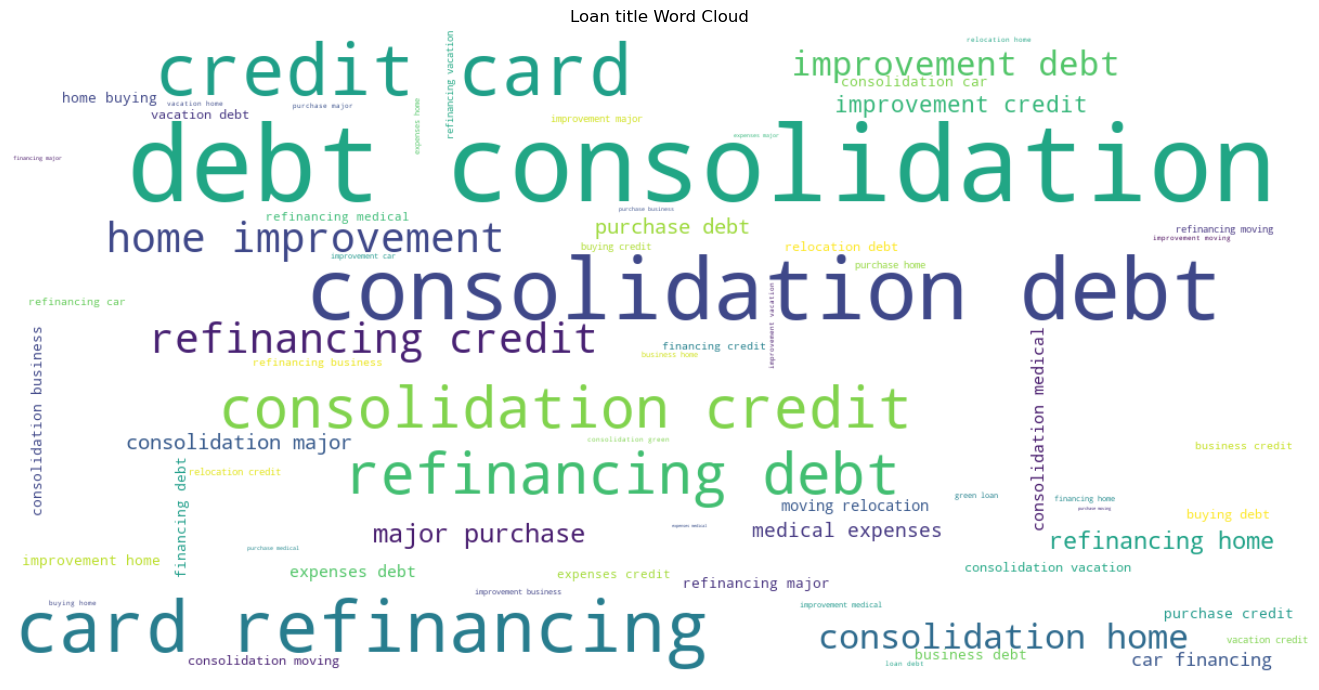

In [226]:
# Word Cloud
# ________________________________________________

logger.info("Generating word cloud...")

text = " ".join(X_train_nlp["clean_title"])

wordcloud = WordCloud(

    width=1200,

    height=600,

    background_color="white",

    max_words=100,

    random_state=42).generate(text)

plt.figure(figsize=(14,7))

plt.imshow(wordcloud,interpolation="bilinear")

plt.axis("off")

plt.title("Loan title Word Cloud")

plt.tight_layout()

plt.savefig(FIGURE_DIR /"word_cloud.png",dpi=300)

plt.show()

# Save wordcloud 
wordcloud.to_file(str(FIGURE_DIR /"word_cloud.png"))

In [227]:
# Business Interpretation
# __________________________________________________________

business_summary = f"""
WORD CLOUD SUMMARY

The word cloud highlights the dominant borrowing titles within the
training portfolio.

The most prominent words represent the largest borrowing categories,
which are likely to contribute the greatest amount of information
during TF-IDF feature engineering.

This qualitative assessment supports the use of textual features
within the credit risk prediction model.

"""

with open(REPORT_DIR /"word_cloud_summary.txt","w",encoding="utf-8"
         
         ) as file:file.write(business_summary)

### TF-IDF Feature Exploration

#### Evaluating the predictive information contained within the cleaned loan title
#### text using Term Frequency-Inverse Document Frequency (TF-IDF)

In [159]:
# create TF-IDF Matrix
# ________________________________________________

tfidf = TfidfVectorizer(max_features=5000,
                        
                        min_df=5
                        
                        ,stop_words="english"
                        ,dtype=np.float32)

tfidf_matrix = tfidf.fit_transform(X_train_nlp["clean_title"])

logger.info(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")

2026-07-03 14:13:58,951 | INFO | TF-IDF Matrix Shape: (400000, 20)


In [160]:
# Extract Vocabulary
# ________________________________________________

feature_names = tfidf.get_feature_names_out()

tfidf_df = pd.DataFrame(tfidf_matrix.toarray()
                        
                        ,columns=feature_names)

display(tfidf_df.head())

,business,buying,car,card,consolidation,credit,debt,expenses,financing,green,home,improvement,loan,major,medical,moving,purchase,refinancing,relocation,vacation
0,0.0,0.0,0.0,0.577349,0.000000,0.577349,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.577352,0.0,0.0
1,0.0,0.0,0.0,0.000000,0.707107,0.000000,0.707107,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
2,0.0,0.0,0.0,0.000000,0.707107,0.000000,0.707107,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
3,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.699372,0.714758,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
4,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.699372,0.714758,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0


In [163]:
# Mean TF-IDF Weight
# ________________________________________________

mean_weights = pd.DataFrame({"Word":feature_names
                             
                             ,"Mean_TFIDF":tfidf_df.mean()})

mean_weights = (mean_weights.sort_values(by="Mean_TFIDF"
                                         
                                         ,ascending=False))

top20_tfidf = mean_weights.head(20)

display(top20_tfidf)

# Save Report

top20_tfidf.to_csv(REPORT_DIR/"top20_tfidf_terms.csv",index=False)

,Word,Mean_TFIDF
consolidation,consolidation,0.411018
debt,debt,0.411018
card,card,0.138444
credit,credit,0.138444
refinancing,refinancing,0.138442
home,home,0.045984
improvement,improvement,0.044271
purchase,purchase,0.013880
major,major,0.013880
business,business,0.008615


In [165]:
# TF-IDF Statistics
# ________________________________________________

statistics = pd.DataFrame({"Metric":["Documents"
                                     
                                     ,"Vocabulary Size"
                                     
                                     ,"Maximum Features"
                                     
                                     ,"Minimum Document Frequency"],
                           
                           "Value":[tfidf_matrix.shape[0]
                                    
                                    ,len(feature_names),
                                    
                                    5000,5]})

statistics.to_csv(REPORT_DIR/"tfidf_feature_statistics.csv",index=False)

display(statistics)

,Metric,Value
0,Documents,400000
1,Vocabulary Size,20
2,Maximum Features,5000
3,Minimum Document Frequency,5


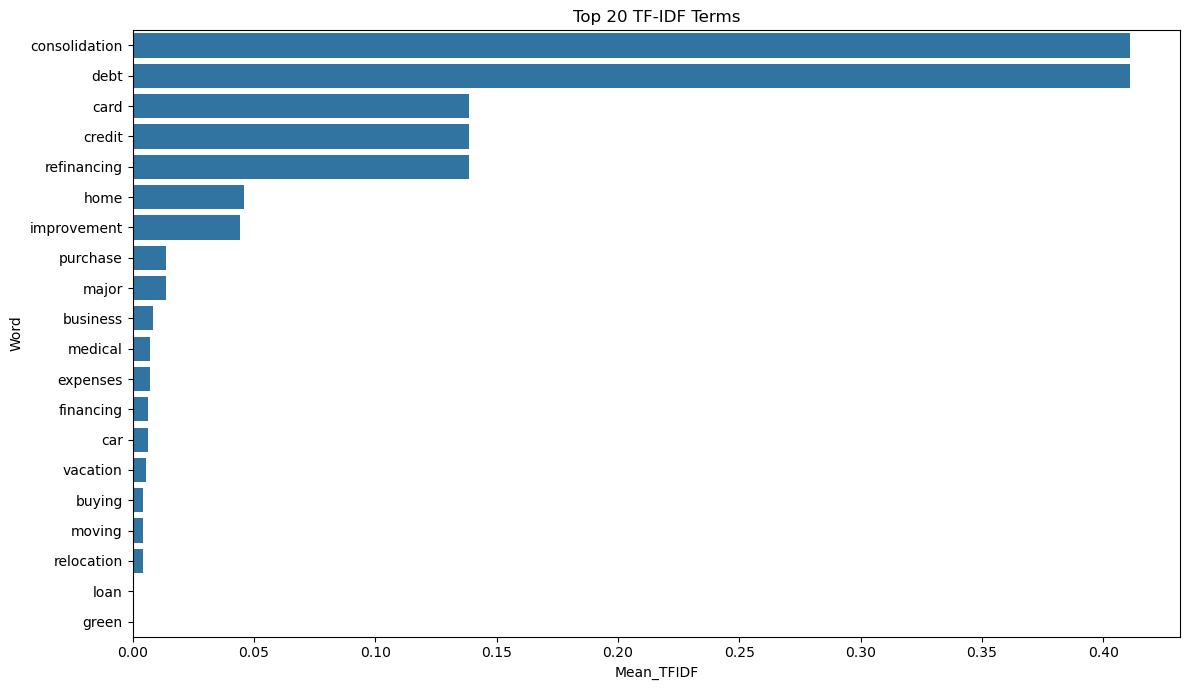

In [166]:
# visualise Top 20 TF-IDF Terms
# ________________________________________________

plt.figure(figsize=(12,7))

sns.barplot(data=top20_tfidf,
            
            x="Mean_TFIDF",
            
            y="Word")

plt.title("Top 20 TF-IDF Terms")

plt.tight_layout()

plt.savefig(FIGURE_DIR/"top20_tfidf_terms.png",dpi=300)

plt.show()

In [169]:
# Business Summary
# ________________________________________________

summary = f"""

TF-IDF FEATURE SUMMARY

Documents analysed:

{tfidf_matrix.shape[0]:,}

Vocabulary Size:

{len(feature_names)}

Maximum Vocabulary:

5000

Minimum Document Frequency:

5

Top Predictive Terms

{', '.join(top20_tfidf.Word.head(10))}

These words will later be combined with the structured
financial variables to produce Matrix C for the final
credit risk prediction models.
"""

print(summary)

with open(REPORT_DIR/"tfidf_summary.txt","w",

    encoding="utf-8") as f:

    f.write(summary)



TF-IDF FEATURE SUMMARY

Documents analysed:

400,000

Vocabulary Size:

20

Maximum Vocabulary:

5000

Minimum Document Frequency:

5

Top Predictive Terms

consolidation, debt, card, credit, refinancing, home, improvement, purchase, major, business

These words will later be combined with the structured
financial variables to produce Matrix C for the final
credit risk prediction models.



In [170]:
# Validate Output
# ________________________________________________

assert tfidf_matrix.shape[0] == len(X_train_nlp)

assert len(feature_names) <= 5000

logger.info("TF-IDF validation completed successfully.")

2026-07-03 15:07:54,756 | INFO | TF-IDF validation completed successfully.


#### Business Risk Analysis (Default Rate by Loan Title)

##### Analysing the relationship between loan purpose and
##### borrower default.

In [192]:
# Creating dataset for Analysis
# ________________________________________________

logger.info("Creating title risk dataset...")

title_analysis = pd.DataFrame({

    "title": X_train_nlp["title"],

    "target": y_train})

display(title_analysis.head())

2026-07-03 20:54:56,218 | INFO | Creating title risk dataset...


,title,target
409428,Credit card refinancing,0
6851,Debt consolidation,0
278277,Debt consolidation,0
427606,Home improvement,0
149465,Home improvement,0


In [182]:
# Calculating Default Rate
# ________________________________________________

logger.info("Calculating default rate by title...")

title_profile = (title_analysis
    
    .groupby("title")

    .agg(Number_of_Loans=("target","count"),
         
         Defaults=("target","sum"),
         
         Default_Rate=("target","mean"))

    .reset_index())

title_profile["Default_Rate"] = (title_profile["Default_Rate"]*100
                                  
                                  ).round(2)

title_profile = (title_profile
    
    .sort_values(by="Default_Rate"
                 
                 ,ascending=False))

display(title_profile)

# Save Report

title_profile.to_csv(REPORT_DIR/"title_default_rate.csv",index=False)

2026-07-03 20:26:25,352 | INFO | Calculating default rate by title...


,title,Number_of_Loans,Defaults,Default_Rate
15,Paying off higher interest cards & auto,1,1,100.00
6,Green loan,204,48,23.53
0,Business,3446,807,23.42
12,Moving and relocation,2335,459,19.66
4,Debt consolidation,232284,41254,17.76
11,Medical expenses,4176,701,16.79
13,Other,21079,3372,16.00
19,Vacation,2225,346,15.55
7,Home buying,2101,321,15.28
10,Major purchase,7852,1189,15.14


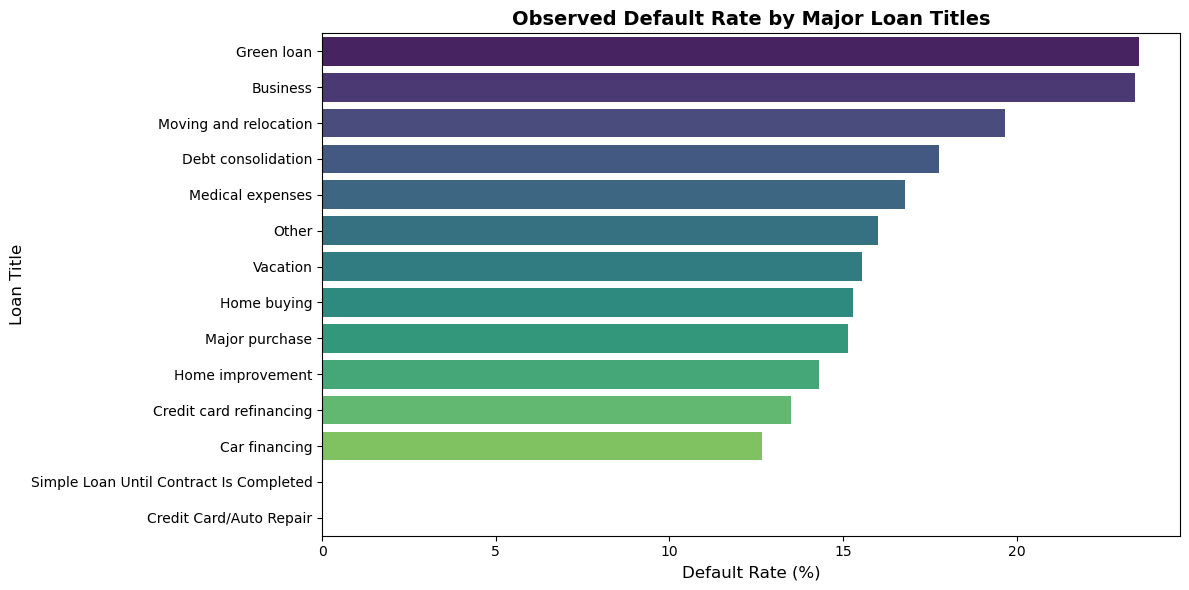

In [195]:
# Visualised Default Rate
# ________________________________________________

# Identifing the major titles with substantial sample 

top_titles = ['title'].value_counts().head(15).index

# Filter profiles to only map top categories

filtered_profile = title_profile[title_profile['title']
    
    .isin(top_titles)].sort_values(
    
    by="Default_Rate", ascending=False)

# Build barplot

plt.figure(figsize=(12, 6))

sns.barplot(data=filtered_profile,
            
            x="Default_Rate",
            
            y="title",
            
            hue="title",
            
            palette="viridis",
            
            legend=False)

# 4. Clean styling and labels
plt.title("Observed Default Rate by Major Loan Titles"
          
          ,fontsize=14
          
          ,fontweight='bold')

plt.xlabel("Default Rate (%)", fontsize=12)

plt.ylabel("Loan Title", fontsize=12)

plt.tight_layout()

plt.savefig(FIGURE_DIR / "clean_title_default_rate.png", dpi=300)

plt.show()

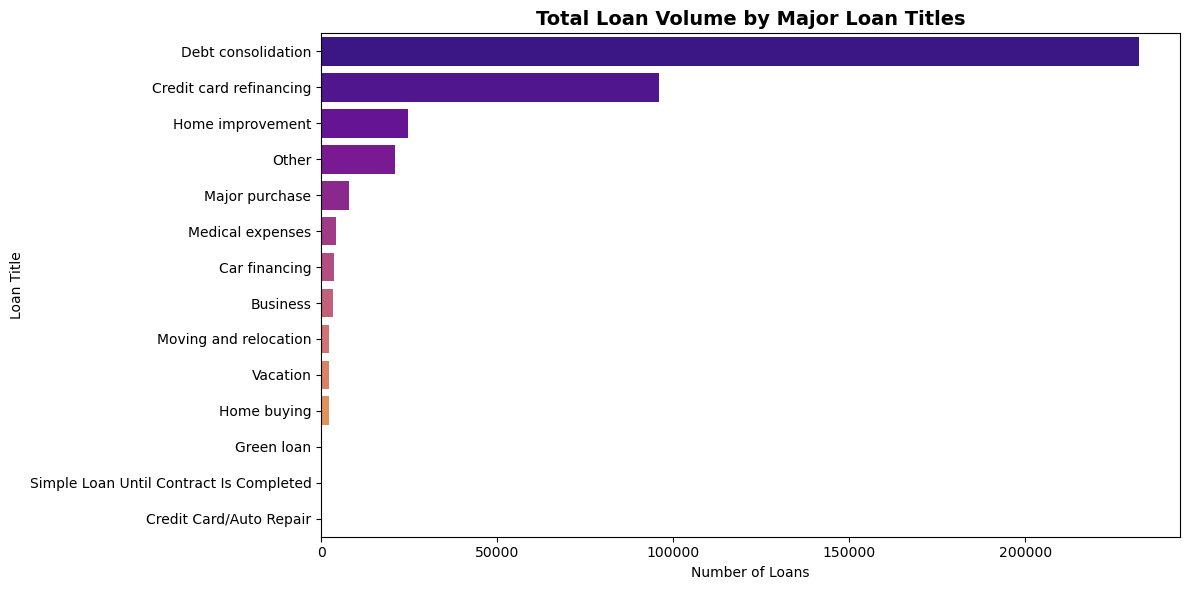

In [196]:
# Visualisation of Loan Volume
# ________________________________________________

# Create bar chart

plt.figure(figsize=(12, 6))

sns.barplot(data=filtered_volume,
            
            x="Number_of_Loans",
            
            y="title",
            
            hue="title",
            
            palette="plasma",
            
            legend=False)

# Add formatting

plt.title("Total Loan Volume by Major Loan Titles"
          
          , fontsize=14
          
          , fontweight='bold')

plt.xlabel("Number of Loans")

plt.ylabel("Loan Title")

plt.tight_layout()

plt.savefig(FIGURE_DIR / "clean_title_loan_volume.png", dpi=300)

plt.show()

In [206]:
# Highest Risk Categories
# ________________________________________________

highest_risk = filtered_profile.sort_values(
    
    by="Default_Rate",
    
    ascending=False).head(5)

print("Top 5 Highest Risk Major Loan Titles")

display(highest_risk)

Top 5 Highest Risk Major Loan Titles


,title,Number_of_Loans,Defaults,Default_Rate
6,Green loan,204,48,23.53
0,Business,3446,807,23.42
12,Moving and relocation,2335,459,19.66
4,Debt consolidation,232284,41254,17.76
11,Medical expenses,4176,701,16.79


In [207]:
# Lowest Risk Categories
# ________________________________________________

lowest_risk = filtered_profile.sort_values(by="Default_Rate"
                                           
                                           , ascending=True).head(5)

print("Top 5 Lowest Risk Major Loan Titles")

display(lowest_risk)

Top 5 Lowest Risk Major Loan Titles


,title,Number_of_Loans,Defaults,Default_Rate
16,Simple Loan Until Contract Is Completed,1,0,0.00
2,Credit Card/Auto Repair,1,0,0.00
1,Car financing,3570,452,12.66
3,Credit card refinancing,95832,12933,13.50
8,Home improvement,24773,3546,14.31


#### NLP EXECUTIVE REPORTING & MODEL READINESS

#### Purpose

##### Summarise the findings from the NLP exploratory analysis and assess
##### whether the loan purpose text is suitable for feature engineering.

In [234]:
# MODEL READINESS REPORT
# ________________________________________________

logger.info("Generating model readiness report...")

model_readiness = pd.DataFrame({"Assessment":["Training Records"
                                              
                                              ,"Missing title (%)"
                                              
                                              ,"Empty Clean title"
                                              
                                              ,"Vocabulary Size"
                                              
                                              ,"Average Words"
                                              
                                              ,"TF-IDF Vocabulary"
                                              
                                              ,"title Categories"
                                              
                                              ,"Suitable for TF-IDF"
                                              
                                              ,"Ready for Feature Engineering"]
                                
                                ,"Value":[len(X_train_nlp)
                                          
                                          ,round(
                                              X_train_nlp["title"].isna().mean()*100,2)
                                          
                                          ,(X_train_nlp["clean_title"]=="").sum()
                                          
                                          ,len(unique_words)
                                          
                                          ,round(X_train_nlp["word_count"].mean(),2)
                                          
                                          ,len(feature_names)
                                          
                                          ,X_train_nlp["title"].nunique()
                                          
                                          ,"Yes","Yes"]})

display(model_readiness)

model_readiness.to_csv(REPORT_DIR/"model_readiness_report.csv",index=False)

2026-07-04 01:00:32,137 | INFO | Generating model readiness report...


,Assessment,Value
0,Training Records,400000
1,Missing title (%),0.03
2,Empty Clean title,21190
3,Vocabulary Size,44
4,Average Words,2.18
5,TF-IDF Vocabulary,20
6,title Categories,24
7,Suitable for TF-IDF,Yes
8,Ready for Feature Engineering,Yes


In [213]:
# Feature Recommendation Report
# ________________________________________________

recommendations = pd.DataFrame({"Feature":["title"
                                           
                                           ,"clean_title"
                                           
                                           ,"TF-IDF Matrix"]
                                
                                ,"Recommendation":["Retain"
                                                   
                                                   ,"Retain"
                                                   
                                                   ,"Generate"]
                                
                                ,"Reason":["Business meaning retained."
                                           
                                           ,"Required for NLP analysis."
                                           
                                           ,"Required for Matrix B."]})

display(recommendations)

# Save Recommendation 

recommendations.to_csv(REPORT_DIR/"feature_recommendations.csv",index=False)

,Feature,Recommendation,Reason
0,title,Retain,Business meaning retained.
1,clean_title,Retain,Required for NLP analysis.
2,TF-IDF Matrix,Generate,Required for Matrix B.


In [218]:
# Executive Summary
# ________________________________________________

sorted_filtered = filtered_profile.sort_values(by="Default_Rate", ascending=False)

highest = sorted_filtered.iloc[0]

lowest = sorted_filtered.iloc[-1]

# Build the formatted summary string
summary = f"""

NLP EXECUTIVE SUMMARY
Explainable AI Credit Risk Decision Platform
________________________________________________________

Dataset Summary
--------------------------------------------------------
Training Records:
{len(X_train_nlp):,}

Loan Title Categories:
{X_train_nlp['title'].nunique()}

Vocabulary Size:
{len(unique_words):,}

Average Loan Title Length:
{X_train_nlp['word_count'].mean():.2f} words

------------------------------------------------------------
Risk Insights (Major Categories)

Highest Observed Default Title:
{highest['title']}
Observed Default Rate:
{highest['Default_Rate']:.2f}%

Lowest Observed Default Title:
{lowest['title']}
Observed Default Rate:
{lowest['Default_Rate']:.2f}%

NLP Assessment
------------------------------------------------------------
✓ Text quality acceptable
✓ Missing values minimal
✓ TF-IDF vocabulary successfully generated
✓ Dataset suitable for NLP feature engineering

____________________________________________________________
"""

# Output to the console
print(summary)

# Save to your local report directory system
with open(REPORT_DIR / "executive_summary.txt", "w", encoding="utf-8") as file:
    file.write(summary)

print(f"Executive summary cleanly saved locally to: {REPORT_DIR / 'executive_summary.txt'}")


NLP EXECUTIVE SUMMARY
Explainable AI Credit Risk Decision Platform

Dataset Summary
------------------------------------------------------------
Training Records:
400,000

Loan Title Categories:
24

Vocabulary Size:
44

Average Loan Title Length:
2.18 words

------------------------------------------------------------
Risk Insights (Major Categories)

Highest Observed Default Title:
Green loan
Observed Default Rate:
23.53%

Lowest Observed Default Title:
Credit Card/Auto Repair
Observed Default Rate:
0.00%

NLP Assessment
------------------------------------------------------------
✓ Text quality acceptable
✓ Missing values minimal
✓ TF-IDF vocabulary successfully generated
✓ Dataset suitable for NLP feature engineering


Executive summary cleanly saved locally to: reports/eda/unstructured/executive_summary.txt


In [219]:
# Business Insights Report

business_report = f"""
BUSINESS INSIGHTS
__________________________________________________________

Portfolio Overview
------------------------------------------------------------
The Lending Club training portfolio contains
{len(X_train_nlp):,} loans.

Borrowers mainly request funding for a limited
set of financial purposes, with debt consolidation,
credit card refinancing, and home improvement
representing the dominant categories.

------------------------------------------------------------
Credit Risk Observations

Observed default rates differ across loan purposes,
suggesting that borrower intention contains useful
credit risk information.

The highest observed risk major title is:
'{highest['title']}'
with a default rate of
{highest['Default_Rate']:.2f}%.

The lowest observed risk major title is:
'{lowest['title']}'
with a default rate of
{lowest['Default_Rate']:.2f}%.

------------------------------------------------------------
Model Development

The loan title field demonstrates sufficient
quality to justify transformation using TF-IDF.

The generated textual representation will be
combined with structured financial variables
during feature engineering to investigate whether
NLP improves predictive performance and
model interpretability.

------------------------------------------------------------
Business Recommendation

Continue with Matrix B generation using TF-IDF
and combine with structured borrower variables
to produce Matrix C for model development.

______________________________________________________________
"""

print(business_report)

# Save cleanly using the established REPORT_DIR variable path
with open(REPORT_DIR / "business_insights.txt","w",encoding="utf-8"
         
         ) as file:file.write(business_report)

print(f"Business insights successfully saved locally to: {REPORT_DIR / 'business_insights.txt'}")


BUSINESS INSIGHTS

Portfolio Overview
------------------------------------------------------------
The Lending Club training portfolio contains
400,000 loans.

Borrowers mainly request funding for a limited
set of financial purposes, with debt consolidation,
credit card refinancing, and home improvement
representing the dominant categories.

------------------------------------------------------------
Credit Risk Observations

Observed default rates differ across loan purposes,
suggesting that borrower intention contains useful
credit risk information.

The highest observed risk major title is:
'Green loan'
with a default rate of
23.53%.

The lowest observed risk major title is:
'Credit Card/Auto Repair'
with a default rate of
0.00%.

------------------------------------------------------------
Model Development

The loan title field demonstrates sufficient
quality to justify transformation using TF-IDF.

The generated textual representation will be
combined with structured financial 

### NLP FEATURE GOVERNANCE REPORT

##### Assess whether the textual feature satisfies quality, governance,
##### reproducibility and deployment requirements before entering the
##### machine learning pipeline.

In [229]:
# Calculating Governance Metrics
# ______________________________________________________________

logger.info("Generating NLP feature governance report...")

total_records = len(X_train_nlp)

missing_records = X_train_nlp["title"].isna().sum()

empty_records = (X_train_nlp["clean_title"] == "").sum()

completion_rate = round((1 - missing_records / total_records) * 100,2)

avg_words = round(X_train_nlp["word_count"].mean(),2)

median_words = round(X_train_nlp["word_count"].median(),2)

max_words = X_train_nlp["word_count"].max()

vocabulary_size = len(unique_words)

purpose_categories = X_train_nlp["title"].nunique()

tfidf_terms = len(feature_names)

2026-07-04 00:53:02,408 | INFO | Generating NLP feature governance report...


In [241]:
# Governance Assessment Table

governance = pd.DataFrame({

    "Governance Area":[

        "Source Feature",

        "Feature Type",

        "Training Records",

        "Missing Records",

        "Completion Rate (%)",

        "Empty Clean Text",

        "Average Words",

        "Median Words",

        "Maximum Words",

        "Vocabulary Size",

        "TF-IDF Vocabulary",

        "Stop Words Removed",

        "Minimum Document Frequency",

        "Maximum TF-IDF Features",

        "Suitable for Modelling",

        "Data Leakage Risk",

        "Deployment Ready"],

    "Assessment":[

        "title",

        "Text",

        total_records,

        missing_records,

        completion_rate,

        empty_records,

        avg_words,

        median_words,

        max_words,

        vocabulary_size,

        tfidf_terms,

        "Yes",

        5,

        5000,

        "Yes",

        "No",

        "Yes"]})

display(governance)

,Governance Area,Assessment
0,Source Feature,title
1,Feature Type,Text
2,Training Records,400000
3,Missing Records,111
4,Completion Rate (%),99.97
5,Empty Clean Text,21190
6,Average Words,2.18
7,Median Words,2.0
8,Maximum Words,7
9,Vocabulary Size,44


In [244]:
# Risk Rating 
# ________________________________________________

def governance_rating(row):

    area = row["Governance Area"]

    value = row["Assessment"]

    if area == "Completion Rate (%)":

        return "PASS" if value >= 95 else "REVIEW"

    if area == "Missing Records":

        return "PASS" if value == 0 else "REVIEW"

    if area == "Empty Clean Text":

        return "PASS" if value < 100 else "REVIEW"

    if area == "Vocabulary Size":

        return "PASS" if value > 10 else "LIMITED"

    if area == "Deployment Ready":

        return "PASS"

    return "PASS"

governance["Status"] = governance.apply(governance_rating,axis=1)

In [243]:
# Governance Recommendation
# ________________________________________________

recommendations = []

for status in governance["Status"]:

    if status == "PASS":

        recommendations.append(

            "Suitable")

    elif status == "REVIEW":

        recommendations.append(

            "Monitor")

    else:

        recommendations.append(

            "Improve")

governance["Recommendation"] = recommendations

In [250]:
# Executive Gorvernance Summary

summary = f"""
============================================================

NLP FEATURE GOVERNANCE REPORT

============================================================

Feature Name

title

------------------------------------------------------------

Quality Assessment

Training Records:
{total_records:,}

Completion Rate:
{completion_rate:.2f}%

Missing Records:
{missing_records}

Vocabulary Size:
{vocabulary_size:,}

Average Words:
{avg_words}

------------------------------------------------------------

Feature Engineering

Cleaning Applied:
YES

Stop Words Removed:
YES

TF-IDF Vocabulary:
{tfidf_terms}

Minimum Document Frequency:
5

Maximum Features:
5000

------------------------------------------------------------

Governance Assessment

Data Leakage Risk:
LOW

Reproducible Pipeline:
YES

Deployment Ready:
YES

Suitable for Matrix B:
YES

============================================================

Overall Recommendation

The loan title feature satisfies the minimum quality
requirements for TF-IDF feature engineering and is approved
for inclusion within the explainable credit risk modelling
pipeline.

============================================================
"""

print(summary)

with open(REPORT_DIR /"nlp_feature_governance_summary.txt","w",

    encoding="utf-8") as file:

    file.write(summary)



NLP FEATURE GOVERNANCE REPORT


Feature Name

title

------------------------------------------------------------

Quality Assessment

Training Records:
400,000

Completion Rate:
99.97%

Missing Records:
111

Vocabulary Size:
44

Average Words:
2.18

------------------------------------------------------------

Feature Engineering

Cleaning Applied:
YES

Stop Words Removed:
YES

TF-IDF Vocabulary:
20

Minimum Document Frequency:
5

Maximum Features:
5000

------------------------------------------------------------

Governance Assessment

Data Leakage Risk:
LOW

Reproducible Pipeline:
YES

Deployment Ready:
YES

Suitable for Matrix B:
YES


Overall Recommendation

The loan title feature satisfies the minimum quality
requirements for TF-IDF feature engineering and is approved
for inclusion within the explainable credit risk modelling
pipeline.




In [248]:
# FINAL VALIDATION
# ________________________________________________

logger.info("Running final NLP validation...")

assert len(X_train_nlp) > 0
assert len(feature_names) > 0
assert len(unique_words) > 0
assert governance.shape[0] > 0
assert X_train_nlp["clean_title"].isnull().sum() == 0

logger.info("NLP EDA completed successfully.")

2026-07-04 01:15:04,434 | INFO | Running final NLP validation...
2026-07-04 01:15:04,460 | INFO | NLP EDA completed successfully.
